**Logistic regression **

In [ ]:
# Import the appropriate libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
df =  pd.read_csv('diabetes.csv')
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


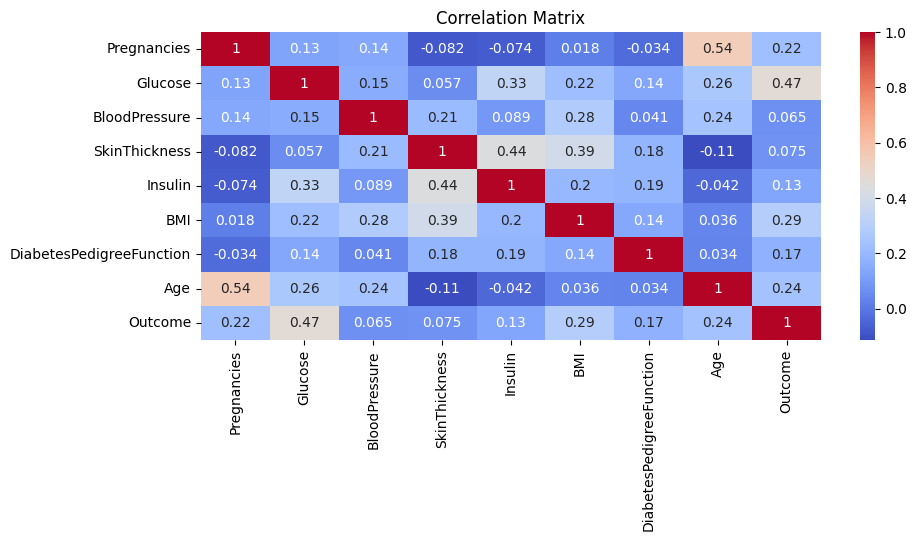

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(10,4))
sns.heatmap(correlation_matrix, annot= True, cmap= 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# k = int(input('enter the required number of features to include in my model' ))
selector = SelectKBest(score_func= f_classif, k= 4)
X_new = selector.fit_transform(X, y)

In [ ]:
# Assuming you have a SelectKBest object named 'selector' and it's already fitted
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = df.columns[selected_feature_indices]

selected_feature_names

Index(['Pregnancies', 'Glucose', 'BMI', 'Age'], dtype='object')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size= 0.2, random_state= 42)

In [ ]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_train_pred = LR.predict(X_train)
y_test_pred = LR.predict(X_test)

In [ ]:
# Calculate the confusion matrices for training and testing
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

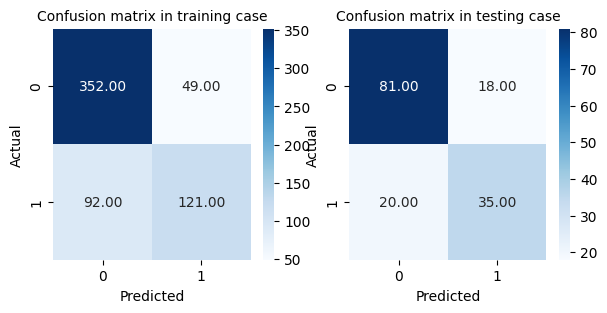

In [ ]:
plt.figure(figsize= (7,3))

plt.subplot(1,2,1)
sns.heatmap(cm_train, annot= True, cmap='Blues', fmt='.2f')
plt.title('Confusion matrix in training case', fontsize=10)
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(cm_test, annot= True, cmap='Blues', fmt='.2f')
plt.title('Confusion matrix in testing case', fontsize=10)
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
# Calculate and display accuracy, precision, specificity, and F1 score
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train= recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

print(f'Accuracy: {accuracy_train:.2f}')
print(f'Precision: {precision_train:.2f}')
print(f'Recall: {recall_train:.2f}')
print(f'F1 Score: {f1_train:.2f}')

Accuracy: 0.77
Precision: 0.71
Recall: 0.57
F1 Score: 0.63


In [ ]:
# Calculate and display accuracy, precision, specificity, and F1 score
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f'Accuracy: {accuracy_test:.2f}')
print(f'Precision: {precision_test:.2f}')
print(f'Recall: {recall_test:.2f}')
print(f'F1 Score: {f1_test:.2f}')

Accuracy: 0.75
Precision: 0.66
Recall: 0.64
F1 Score: 0.65


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
    }

    return pd.DataFrame(metrics, index=[0])

# Example usage:
metrics_train = calculate_metrics(y_train, y_train_pred)
metrics_test = calculate_metrics(y_test, y_test_pred)

# Combine the metrics into a single DataFrame
all_metrics = pd.concat([metrics_train, metrics_test], keys=['Training', 'Testing'])
all_metrics

,,Accuracy,Precision,Recall,F1 Score
Training,0,0.770358,0.711765,0.568075,0.631854
Testing,0,0.753247,0.660377,0.636364,0.648148


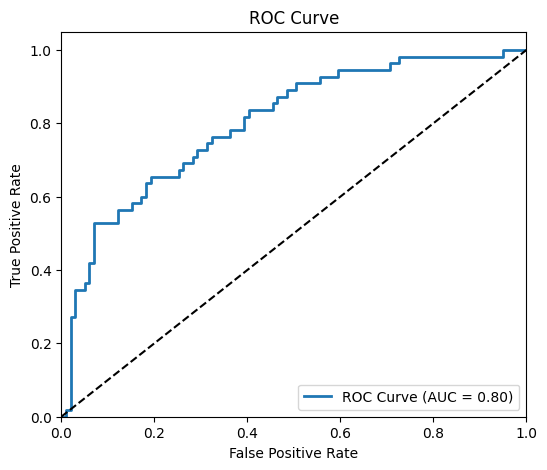

In [ ]:
# Calculate and plot the ROC curve
y_prob = LR.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()